In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from alibi.explainers import ALE
from alibi.explainers import plot_ale


In [2]:
data = pd.read_csv("data/abalone.data",
names=["sex", "length", "diameter", "height", "whole weight", "shucked weight", "viscera weight", "shell weight", "rings"])

In [3]:
y = data["rings"]
X =data[["sex", "length", "height","shucked weight","viscera weight", "shell weight"]]

In [4]:
X['sex.M'] = [1 if s == 'M' else 0 for s in X['sex']]
X['sex.F'] = [1 if s == 'F' else 0 for s in X['sex']]
X['sex.I'] = [1 if s == 'I' else 0 for s in X['sex']]

X = X.drop('sex', axis=1)
X.head()


C:\Users\yssin\AppData\Local\Temp\ipykernel_22104\2676903011.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['sex.M'] = [1 if s == 'M' else 0 for s in X['sex']]
C:\Users\yssin\AppData\Local\Temp\ipykernel_22104\2676903011.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['sex.F'] = [1 if s == 'F' else 0 for s in X['sex']]


,length,height,shucked weight,viscera weight,shell weight,sex.M,sex.F,sex.I
0,0.455,0.095,0.2245,0.1010,0.150,1,0,0
1,0.350,0.090,0.0995,0.0485,0.070,1,0,0
2,0.530,0.135,0.2565,0.1415,0.210,0,1,0
3,0.440,0.125,0.2155,0.1140,0.155,1,0,0
4,0.330,0.080,0.0895,0.0395,0.055,0,0,1


In [5]:
model = RandomForestRegressor()
model.fit(X.to_numpy(), y)

RandomForestRegressor()

In [6]:
ale = ALE (model.predict,
            feature_names=X.columns,
             target_names=['rings'])

In [7]:
exp = ale.explain (X.to_numpy())

array([[<Axes: xlabel='length', ylabel='ALE'>,
        <Axes: xlabel='height', ylabel='ALE'>,
        <Axes: xlabel='shucked weight', ylabel='ALE'>]], dtype=object)

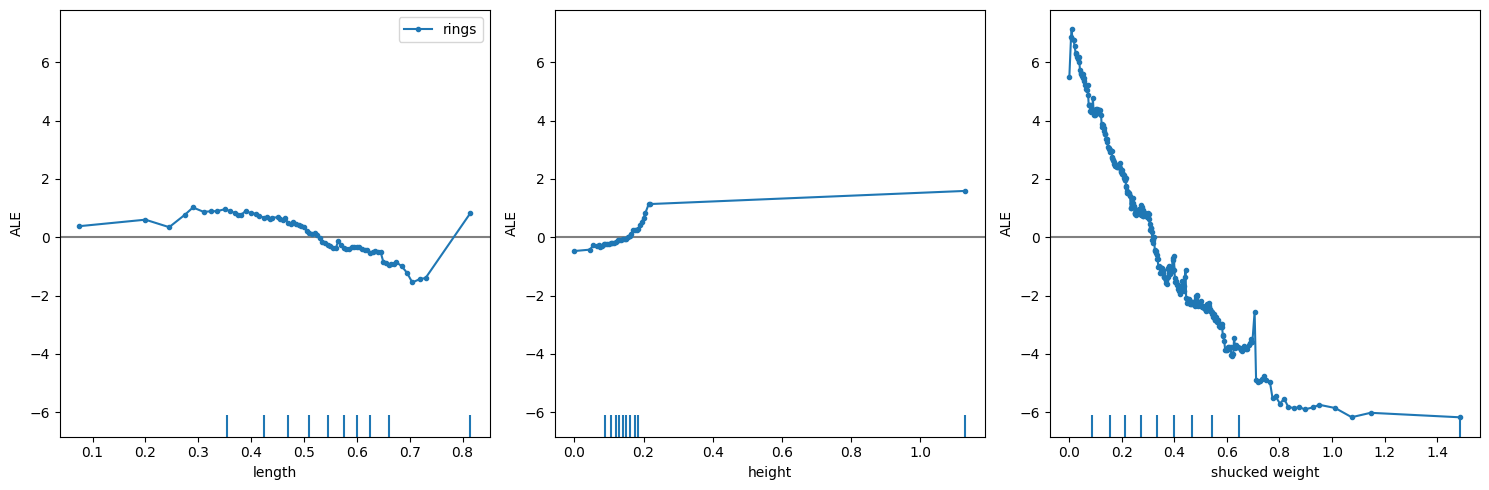

In [ ]:
plot_ale(exp, features=[0,1,2], 
         fig_kw={'figwidth':15, 'figheight':5})


Text(0.5, 0, 'weight')

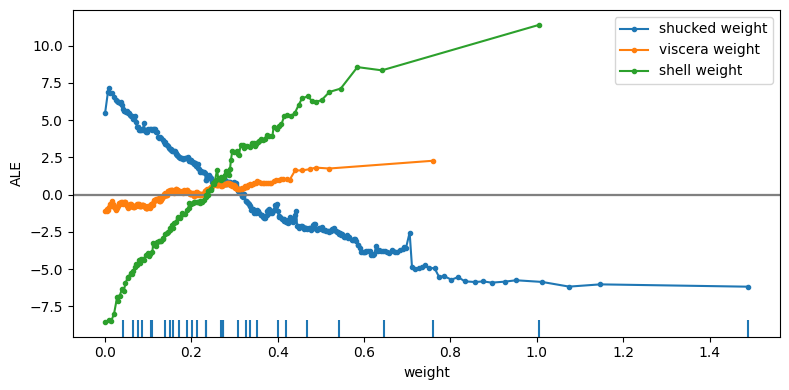

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(8,4))
plot_ale(exp, features=[2], ax=ax, line_kw={'label': 'shucked weight'})
plot_ale(exp, features=[3], ax=ax, line_kw={'label': 'viscera weight'})
plot_ale(exp, features=[4], ax=ax, line_kw={'label': 'shell weight'})
ax.set_xlabel('weight')

In [13]:
ale = ALE(model.predict, 
          feature_names=X.columns, 
          target_names=['rings'])
exp = ale.explain(X.to_numpy(), min_bin_points=50)

Text(0.5, 0, 'weight')

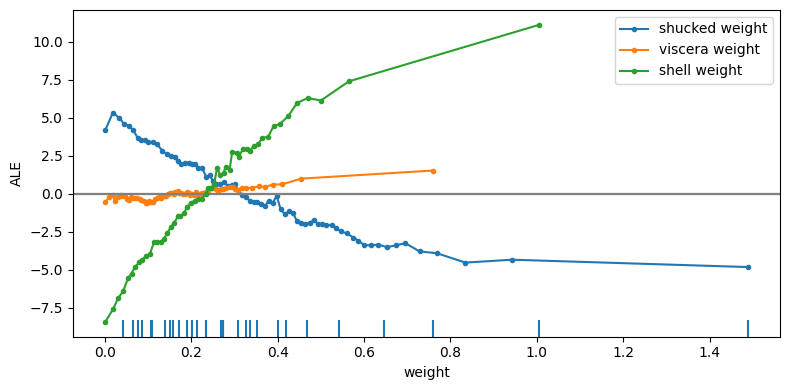

In [14]:
fig, ax = plt.subplots (1, 1, figsize=(8, 4))

plot_ale(exp, features=[2], ax=ax, line_kw={ 'label': 'shucked weight'})
plot_ale(exp, features=[3], ax=ax, line_kw={'label': 'viscera weight'})
plot_ale(exp, features=[4], ax=ax, line_kw={ 'label': 'shell weight'})
ax.set_xlabel('weight')